# 03 - LightGBM Model

Ce notebook entraine un modele LightGBM pour la prevision des ventes.
**Code directement base sur `train.py` pour des resultats identiques.**

**Outputs:**
- `models/artifacts/lgbm_model_YYYYMMDD.pkl`
- `models/artifacts/lgbm_config_YYYYMMDD.json`
- `models/artifacts/lgbm_encoders_YYYYMMDD.json`
- `models/metrics/lgbm_metrics_YYYYMMDD.json`
- `models/metrics/lgbm_feature_importance_YYYYMMDD.csv`

In [1]:
import sys
import json
import datetime
import warnings
import re
from pathlib import Path
from math import sqrt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')

# Setup project path - SAME AS train.py
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\richa\Prediction_de_vente\Prediction_de_vente


In [2]:
# ============================================================
# CONFIGURATION - SAME AS train.py
# ============================================================
HORIZON = 14
LAGS = [14, 21, 28, 35, 42]  # All >= HORIZON
WINDOWS = [14, 21, 28]       # All >= HORIZON
DATE_COL = 'date'
TARGET_COL = 'value'
TODAY = datetime.datetime.now().strftime("%Y%m%d")

# Paths - SAME AS train.py
ARTIFACTS_PATH = PROJECT_ROOT / "models" / "artifacts"
METRICS_PATH = PROJECT_ROOT / "models" / "metrics"
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# Import project config
try:
    from src.config import (
        TRAIN_CSV, GROUP_COLS, FEATURE_EXCLUDE, 
        CATEGORICAL_FEATURES, PREDICT_LAGS, PREDICT_WINDOWS
    )
    # Use config values if available
    LAGS = [l for l in PREDICT_LAGS if l >= HORIZON] or LAGS
    WINDOWS = [w for w in PREDICT_WINDOWS if w >= HORIZON] or WINDOWS
except ImportError:
    TRAIN_CSV = PROJECT_ROOT / "data" / "interim" / "train.csv"
    GROUP_COLS = ['store_id', 'product_id']
    FEATURE_EXCLUDE = {'date', 'value', 'store_id', 'product_id', 'id'}
    CATEGORICAL_FEATURES = ['store_id', 'product_id']

try:
    from src.data.features import build_feature_pipeline
    from src.data.clean import clean_dataframe
    PIPELINE_AVAILABLE = True
except ImportError:
    PIPELINE_AVAILABLE = False
    print("Warning: src.data modules not available")

print(f"Config: HORIZON={HORIZON}, LAGS={LAGS}, WINDOWS={WINDOWS}")

Config: HORIZON=14, LAGS=[14, 21, 28], WINDOWS=[14, 28]


In [3]:
# Find data file - SAME LOGIC AS train.py main()
def find_data_file():
    candidates = [
        TRAIN_CSV,
        PROJECT_ROOT / "data" / "processed" / "uploaded_generated_training_10950_features.csv",
        PROJECT_ROOT / "data" / "processed" / "train_features.csv",
    ]
    for folder in ["interim", "processed", "raw"]:
        folder_path = PROJECT_ROOT / "data" / folder
        if folder_path.exists():
            for f in folder_path.glob("*.csv"):
                candidates.append(f)
    
    for p in candidates:
        if p and p.exists():
            return p
    raise FileNotFoundError("No data file found")

DATA_PATH = find_data_file()
print(f"Data: {DATA_PATH}")

Data: C:\Users\richa\Prediction_de_vente\Prediction_de_vente\data\interim\train.csv


## 1. Load and Prepare Data (COPY FROM train.py load_and_prepare)

In [4]:
# Load data - EXACT COPY FROM train.py load_and_prepare()
print(f"[train] Loading raw data from {DATA_PATH}")
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
print(f"Raw shape: {df.shape}")

# Apply cleaning - SAME AS train.py
if PIPELINE_AVAILABLE:
    try:
        df = clean_dataframe(df, date_col=DATE_COL, value_col=TARGET_COL, 
                             fill_strategy='ffill', outlier_threshold=None)
        print("[train] Applied clean_dataframe sanitization")
    except Exception as e:
        print(f"[train] clean_dataframe failed: {e}")

# Remove pre-computed short-horizon columns - SAME AS train.py
short_col_re = re.compile(
    r"^(?:lag|roll_mean|roll_std|roll_min|roll_max|roll_range|roll_cv|ewma|lag_diff|lag_ratio)_(\d+)"
)
cols_to_drop = [c for c in df.columns if (m := short_col_re.match(c)) and int(m.group(1)) < HORIZON]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"[train] Dropped {len(cols_to_drop)} short-horizon columns (horizon={HORIZON})")

# Remap columns - SAME AS train.py
if 'store_id' not in df.columns and 'id' in df.columns:
    df = df.rename(columns={'id': 'store_id'})
    print("[train] Remapped 'id' -> 'store_id'")

# Handle on_promo - SAME AS train.py
if 'on_promo' in df.columns:
    df['on_promo'] = df['on_promo'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0}
    ).fillna(0).astype(int)

# Detect group columns - SAME AS train.py
available_groups = [c for c in GROUP_COLS if c in df.columns]
print(f"[train] Group columns detected: {available_groups}")
if available_groups:
    n_groups = df.groupby(available_groups).ngroups
    print(f"[train] Number of distinct groups: {n_groups}")

# Sort by group + date - SAME AS train.py
sort_cols = available_groups + [DATE_COL]
df = df.sort_values(sort_cols).reset_index(drop=True)

[train] Loading raw data from C:\Users\richa\Prediction_de_vente\Prediction_de_vente\data\interim\train.csv
Raw shape: (8205, 7)
[train] Applied clean_dataframe sanitization
[train] Group columns detected: ['store_id', 'product_id']
[train] Number of distinct groups: 15


In [5]:
# Build feature pipeline - SAME AS train.py
if PIPELINE_AVAILABLE:
    cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]
    
    df, encoders = build_feature_pipeline(
        df,
        lags=LAGS,
        windows=WINDOWS,
        group_cols=available_groups if available_groups else None,
        categorical_cols=cat_cols if cat_cols else None,
        is_train=True,
        horizon=HORIZON,
    )
    print(f"[train] Features built, shape: {df.shape}")
else:
    encoders = {}
    print("[train] Feature pipeline not available")

# Drop NaN rows - SAME AS train.py
before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)
if before != after:
    print(f"[train] Dropped {before - after} NaN rows (from lags/rolling warm-up)")

[train] Features built, shape: (8205, 51)
[train] Dropped 420 NaN rows (from lags/rolling warm-up)


In [6]:
print(f"\n[train] Dataset shape after feature engineering: {df.shape}")
print(f"[train] Target stats: mean={df[TARGET_COL].mean():.2f}, std={df[TARGET_COL].std():.2f}, min={df[TARGET_COL].min():.2f}, max={df[TARGET_COL].max():.2f}")


[train] Dataset shape after feature engineering: (7785, 51)
[train] Target stats: mean=1136.84, std=9745.06, min=0.00, max=284905.00


## 2. Train/Test Split (COPY FROM train.py split_time_series)

In [7]:
# Split - EXACT COPY FROM train.py split_time_series()
def split_time_series(df, horizon, date_col, target_col, exclude_cols):
    exclude_cols = set(exclude_cols) | {target_col, date_col}
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    unique_dates = sorted(df[date_col].unique())
    if horizon >= len(unique_dates):
        horizon = max(1, len(unique_dates) // 5)
        print(f"[train] Adjusted horizon to {horizon}")
    
    cutoff_date = unique_dates[-horizon]
    train_mask = df[date_col] < cutoff_date
    test_mask = df[date_col] >= cutoff_date
    
    X_train = df.loc[train_mask, feature_cols].copy()
    y_train = df.loc[train_mask, target_col].copy()
    X_test = df.loc[test_mask, feature_cols].copy()
    y_test = df.loc[test_mask, target_col].copy()
    dates_test = df.loc[test_mask, date_col].copy()
    
    return X_train, y_train, X_test, y_test, dates_test

X_train, y_train, X_test, y_test, dates_test = split_time_series(
    df, HORIZON, DATE_COL, TARGET_COL, FEATURE_EXCLUDE
)

print(f"[train] Train: {len(y_train)} samples, Test: {len(y_test)} samples")
print(f"[train] Feature columns ({X_train.shape[1]}): {list(X_train.columns)[:15]}...")

[train] Train: 7575 samples, Test: 210 samples
[train] Feature columns (48): ['store_id', 'product_id', 'price', 'on_promo', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'quarter', 'week_of_year', 'dayofyear', 'day_of_month', 'is_month_start', 'is_month_end']...


In [8]:
# Create validation set - SAME AS train.py
val_size = max(int(len(X_train) * 0.15), HORIZON)
X_tr = X_train.iloc[:-val_size]
y_tr = y_train.iloc[:-val_size]
X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]

print(f"[train] Train/Val split: {len(X_tr)} / {len(X_val)} for early stopping")

[train] Train/Val split: 6439 / 1136 for early stopping


In [9]:
# CRITICAL: Coerce object columns - EXACT COPY FROM train.py _coerce_object_columns()
def _coerce_object_columns(df_in):
    """Ensure all columns are numeric for tree models - SAME AS train.py"""
    df_out = df_in.copy()
    for c in df_out.columns:
        if pd.api.types.is_object_dtype(df_out[c].dtype) or isinstance(df_out[c].dtype, pd.CategoricalDtype):
            try:
                df_out[c] = pd.Categorical(df_out[c]).codes
            except Exception:
                df_out[c] = pd.to_numeric(df_out[c], errors='coerce').fillna(0).astype(float)
    return df_out

X_tr = _coerce_object_columns(X_tr)
X_val = _coerce_object_columns(X_val)
X_test = _coerce_object_columns(X_test)
X_train_full = _coerce_object_columns(X_train)

# Full feature set for CV
exclude_cols = set(FEATURE_EXCLUDE) | {TARGET_COL, DATE_COL}
feature_cols = [c for c in df.columns if c not in exclude_cols]
X_all = _coerce_object_columns(df[feature_cols].copy())
y_all = df[TARGET_COL].copy()

print("[train] Columns coerced to numeric")

[train] Columns coerced to numeric


## 3. LightGBM Training (COPY FROM train.py)

In [10]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

# Default params - EXACT COPY FROM train.py _default_lgbm_params()
lgbm_params = {
    'n_estimators': 1000,
    'max_depth': 8,
    'learning_rate': 0.03,
    'num_leaves': 24,
    'min_child_samples': 30,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbosity': -1,
    'n_jobs': -1,
}

print("[train] LightGBM params:")
for k, v in lgbm_params.items():
    print(f"  {k}: {v}")

[train] LightGBM params:
  n_estimators: 1000
  max_depth: 8
  learning_rate: 0.03
  num_leaves: 24
  min_child_samples: 30
  subsample: 0.8
  colsample_bytree: 0.8
  feature_fraction: 0.8
  bagging_fraction: 0.8
  bagging_freq: 5
  reg_alpha: 0.1
  reg_lambda: 0.1
  random_state: 42
  verbosity: -1
  n_jobs: -1


In [11]:
# Train LightGBM - EXACT COPY FROM train.py train_lgbm()
print("\n[train] Training LightGBM...")

model = LGBMRegressor(**lgbm_params)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=-1),
    ],
)

print(f"[train] LightGBM best iteration: {model.best_iteration_}")


[train] Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[253]	valid_0's l2: 3321.72
[train] LightGBM best iteration: 253


## 4. Evaluation (COPY FROM train.py evaluate_model)

In [12]:
# Evaluate - EXACT LOGIC FROM train.py evaluate_model()
def evaluate_model(model, X_train, y_train, X_test, y_test, X_all, y_all, n_cv_splits=5):
    # Train predictions
    y_pred_train = model.predict(X_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    bias_train = float(np.mean(y_pred_train - y_train))
    
    # Test predictions
    y_pred_test = model.predict(X_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    bias_test = float(np.mean(y_pred_test - y_test))
    
    # Bias-corrected
    y_pred_corrected = y_pred_test - bias_test
    mae_corrected = mean_absolute_error(y_test, y_pred_corrected)
    rmse_corrected = sqrt(mean_squared_error(y_test, y_pred_corrected))
    r2_corrected = r2_score(y_test, y_pred_corrected)
    
    # Safe MAPE - SAME AS train.py
    y_test_arr = np.array(y_test)
    mask = np.abs(y_test_arr) > 1.0
    mape = float(np.mean(np.abs((y_test_arr[mask] - y_pred_test[mask]) / y_test_arr[mask])) * 100) if mask.sum() > 0 else None
    
    # sMAPE - SAME AS train.py
    denom = (np.abs(y_test_arr) + np.abs(y_pred_test)) / 2
    denom_safe = np.where(denom > 0, denom, 1.0)
    smape = float(np.mean(np.abs(y_test_arr - y_pred_test) / denom_safe) * 100)
    
    # Cross-validation - SAME AS train.py
    tscv = TimeSeriesSplit(n_splits=min(n_cv_splits, max(2, len(X_all) // 100)))
    cv_scores = {'mae': [], 'r2': []}
    
    for train_idx, val_idx in tscv.split(X_all):
        X_cv_tr, X_cv_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_cv_tr, y_cv_val = y_all.iloc[train_idx], y_all.iloc[val_idx]
        
        model_cv = LGBMRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            random_state=42, verbosity=-1, n_jobs=-1,
        )
        model_cv.fit(
            X_cv_tr, y_cv_tr,
            eval_set=[(X_cv_val, y_cv_val)],
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(-1)],
        )
        
        y_cv_pred = model_cv.predict(X_cv_val)
        cv_scores['mae'].append(mean_absolute_error(y_cv_val, y_cv_pred))
        cv_scores['r2'].append(r2_score(y_cv_val, y_cv_pred))
    
    overfit_ratio = rmse_test / rmse_train if rmse_train > 0 else float('inf')
    
    return {
        'MAE_train': mae_train, 'RMSE_train': rmse_train, 'R2_train': r2_train, 'Bias_train': bias_train,
        'MAE_test': mae_test, 'RMSE_test': rmse_test, 'R2_test': r2_test, 'Bias_test': bias_test,
        'MAE_test_corrected': mae_corrected, 'RMSE_test_corrected': rmse_corrected, 'R2_test_corrected': r2_corrected,
        'MAPE_test': mape, 'sMAPE_test': smape,
        'overfit_ratio': overfit_ratio,
        'CV_mae_mean': np.mean(cv_scores['mae']), 'CV_mae_std': np.std(cv_scores['mae']),
        'CV_r2_mean': np.mean(cv_scores['r2']), 'CV_r2_std': np.std(cv_scores['r2']),
        'y_pred_test': y_pred_test,
    }

In [13]:
# Evaluate
metrics = evaluate_model(model, X_train_full, y_train, X_test, y_test, X_all, y_all)

# Print results - SAME FORMAT AS train.py
print("\n" + "="*60)
print("[train] Model type: LightGBM")
print("="*60)
print(f"  Train  -> MAE={metrics['MAE_train']:.4f}  RMSE={metrics['RMSE_train']:.4f}  R2={metrics['R2_train']:.4f}")
print(f"  Test   -> MAE={metrics['MAE_test']:.4f}  RMSE={metrics['RMSE_test']:.4f}  R2={metrics['R2_test']:.4f}")
print(f"  Test*  -> MAE={metrics['MAE_test_corrected']:.4f}  RMSE={metrics['RMSE_test_corrected']:.4f}  R2={metrics['R2_test_corrected']:.4f}  (* bias-corrected)")
print(f"  Bias   -> train={metrics['Bias_train']:.4f}  test={metrics['Bias_test']:.4f}")
print(f"  MAPE   -> {metrics['MAPE_test']:.2f}%" if metrics['MAPE_test'] else "  MAPE   -> N/A")
print(f"  sMAPE  -> {metrics['sMAPE_test']:.2f}%")
print(f"  Overfit ratio (RMSE_test/RMSE_train): {metrics['overfit_ratio']:.2f}")
print(f"  CV     -> MAE={metrics['CV_mae_mean']:.4f} (+/- {metrics['CV_mae_std']:.4f})")
print(f"  CV     -> R2={metrics['CV_r2_mean']:.4f} (+/- {metrics['CV_r2_std']:.4f})")
print("="*60)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[81]	valid_0's l2: 63507.7
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[64]	valid_0's l2: 292450
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[55]	valid_0's l2: 41512
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[116]	valid_0's l2: 4479.72
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[320]	valid_0's l2: 4856.24

[train] Model type: LightGBM
  Train  -> MAE=267.1031  RMSE=3601.5082  R2=0.8671
  Test   -> MAE=75.3682  RMSE=163.5365  R2=0.8998
  Test*  -> MAE=86.1399  RMSE=159.7001  R2=0.9045  (* bias-corrected)
  Bias   -> train=-4.8519  test=-35.2145
  MAPE   -> 11.67%
  sMAPE  -> 61.93%
  Overfit ratio (RMSE_test/RMSE_train): 0.05
  CV     -> MAE=166.5116 (+/- 136.0899)
  CV     -> R2=0.431

In [14]:
# Verdict - SAME AS train.py
r2 = metrics['R2_test']
if r2 >= 0.8:
    verdict = "Excellent model -- strong predictive power."
elif r2 >= 0.6:
    verdict = "Good model -- reasonable predictions."
elif r2 >= 0.4:
    verdict = "Fair model -- some predictive power."
else:
    verdict = "Weak model -- consider feature engineering or data quality."

print(f"  VERDICT: {verdict}")

  VERDICT: Excellent model -- strong predictive power.


## 5. Feature Importance

In [15]:
# Feature importance - SAME AS train.py get_feature_importance()
fi = pd.DataFrame({
    'feature': X_train_full.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 20 features:")
print(fi.head(20).to_string())


Top 20 features:
            feature  importance
0           ewma_14         400
1            lag_21         256
2            lag_28         255
3       roll_min_14         243
4         dayofweek         228
5            lag_14         207
6           ewma_28         194
7       roll_max_28         183
8       roll_max_14         179
9      roll_mean_14         143
10       roll_cv_14         122
11    roll_range_28         120
12      roll_std_28         107
13      roll_std_14          97
14       roll_cv_28          93
15    roll_range_14          93
16     roll_mean_28          82
17      roll_min_28          81
18  day_of_year_cos          70
19          dow_sin          65


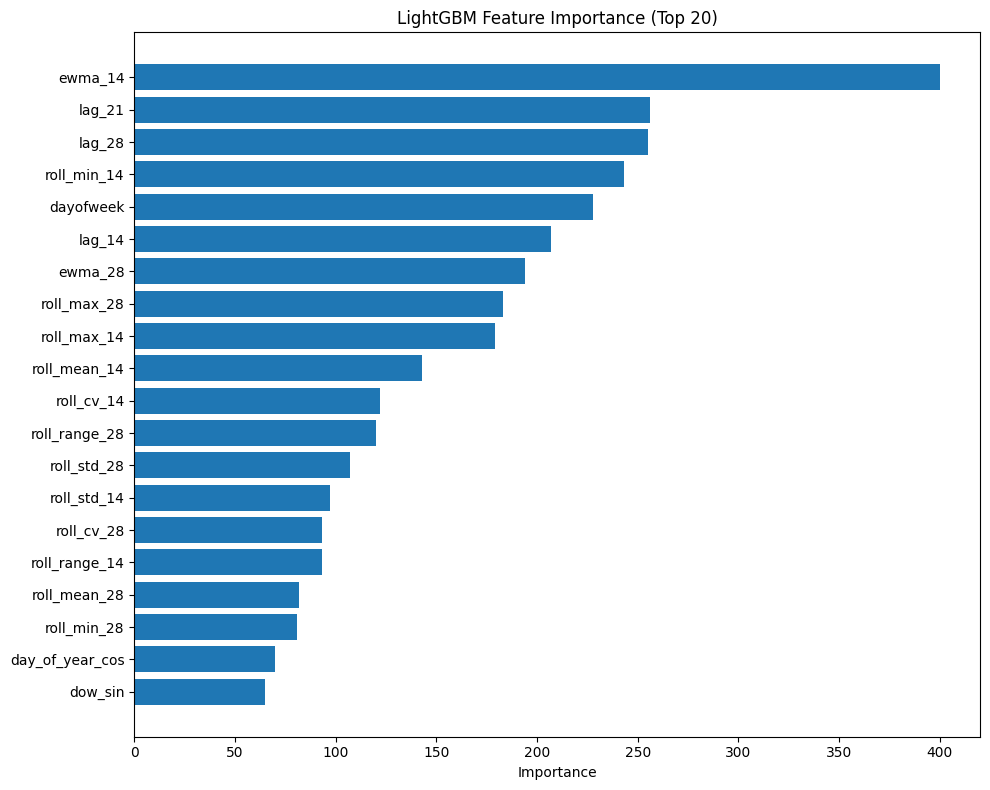

In [16]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(fi))
ax.barh(fi['feature'].head(top_n)[::-1], fi['importance'].head(top_n)[::-1])
ax.set_xlabel('Importance')
ax.set_title('LightGBM Feature Importance (Top 20)')
plt.tight_layout()
plt.savefig(METRICS_PATH / f"lgbm_feature_importance_{TODAY}.png", dpi=150)
plt.show()

## 6. Visualizations

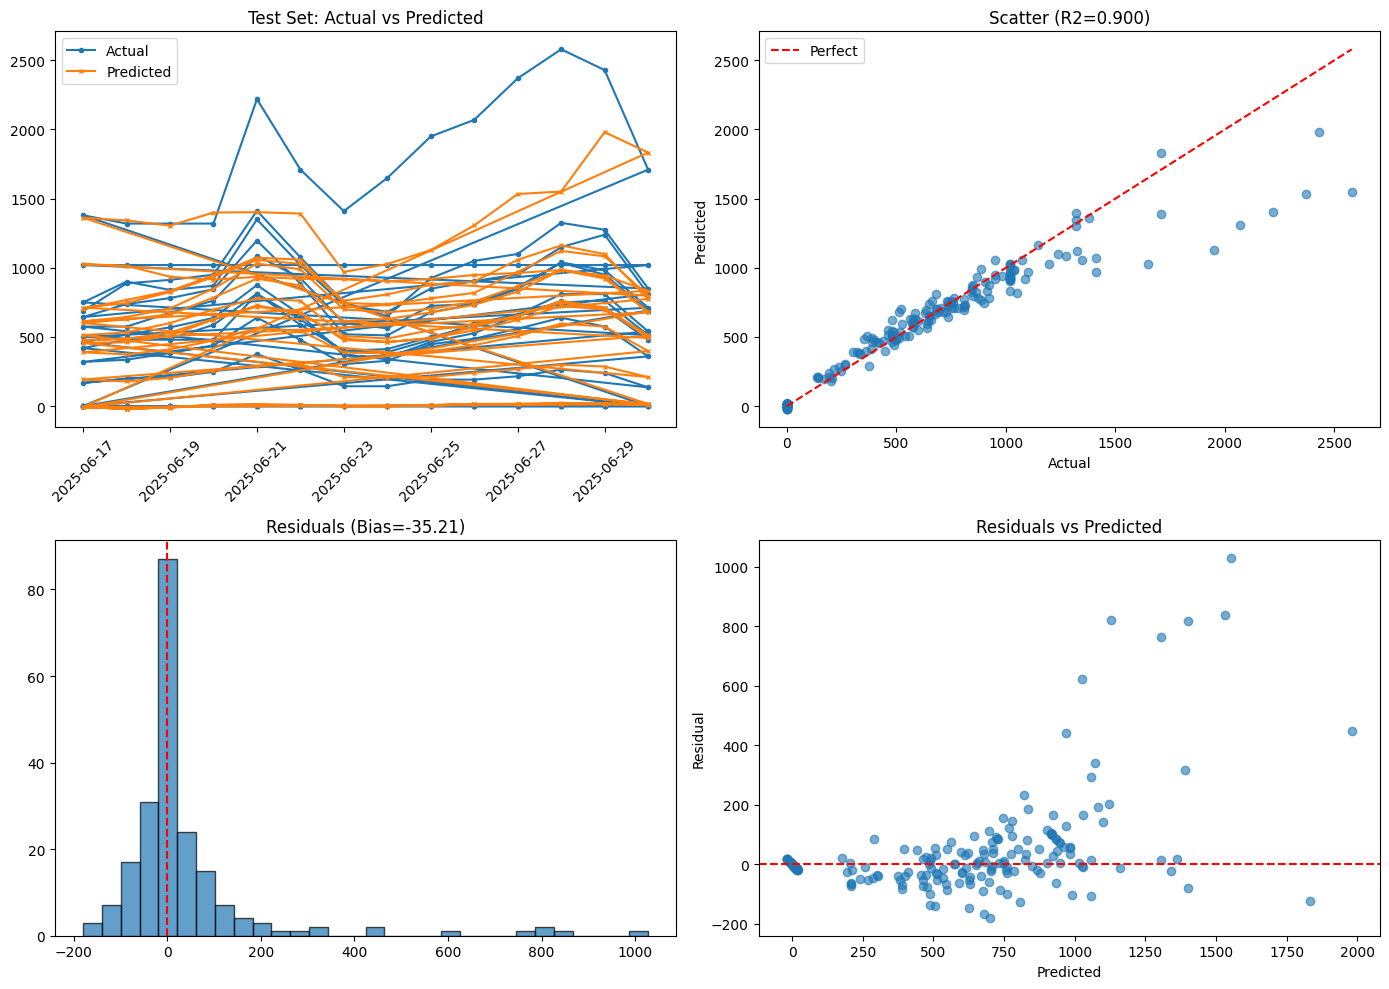

In [17]:
y_pred = metrics['y_pred_test']
y_true = y_test.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time series
ax1 = axes[0, 0]
ax1.plot(dates_test.values, y_true, label='Actual', marker='o', markersize=3)
ax1.plot(dates_test.values, y_pred, label='Predicted', marker='x', markersize=3)
ax1.set_title('Test Set: Actual vs Predicted')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# 2. Scatter
ax2 = axes[0, 1]
ax2.scatter(y_true, y_pred, alpha=0.6)
max_val = max(y_true.max(), y_pred.max())
ax2.plot([0, max_val], [0, max_val], 'r--', label='Perfect')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Scatter (R2={metrics["R2_test"]:.3f})')
ax2.legend()

# 3. Residuals histogram
ax3 = axes[1, 0]
residuals = y_true - y_pred
ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='red', linestyle='--')
ax3.set_title(f'Residuals (Bias={metrics["Bias_test"]:.2f})')

# 4. Residuals vs Predicted
ax4 = axes[1, 1]
ax4.scatter(y_pred, residuals, alpha=0.6)
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Residual')
ax4.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig(METRICS_PATH / f"lgbm_plots_{TODAY}.png", dpi=150)
plt.show()

## 7. Save Artifacts & Metrics (SAME AS train.py save_artifacts)

In [18]:
# Compile all metrics
all_metrics = {
    'model_type': 'LightGBM',
    'timestamp': datetime.datetime.now().isoformat(),
    'horizon': HORIZON,
    'lags': LAGS,
    'windows': WINDOWS,
    'num_train_samples': len(X_train_full),
    'num_test_samples': len(X_test),
    'num_features': X_train_full.shape[1],
    'feature_names': list(X_train_full.columns),
    'best_iteration': model.best_iteration_,
    
    # Train metrics
    'MAE_train': float(metrics['MAE_train']),
    'RMSE_train': float(metrics['RMSE_train']),
    'R2_train': float(metrics['R2_train']),
    'Bias_train': float(metrics['Bias_train']),
    
    # Test metrics
    'MAE_test': float(metrics['MAE_test']),
    'RMSE_test': float(metrics['RMSE_test']),
    'R2_test': float(metrics['R2_test']),
    'Bias_test': float(metrics['Bias_test']),
    
    # Corrected
    'MAE_test_corrected': float(metrics['MAE_test_corrected']),
    'RMSE_test_corrected': float(metrics['RMSE_test_corrected']),
    'R2_test_corrected': float(metrics['R2_test_corrected']),
    
    # Other metrics
    'MAPE_test': metrics['MAPE_test'],
    'sMAPE_test': float(metrics['sMAPE_test']),
    'overfit_ratio': float(metrics['overfit_ratio']),
    
    # CV
    'CV_mae_mean': float(metrics['CV_mae_mean']),
    'CV_mae_std': float(metrics['CV_mae_std']),
    'CV_r2_mean': float(metrics['CV_r2_mean']),
    'CV_r2_std': float(metrics['CV_r2_std']),
}

# Save metrics JSON
metrics_file = METRICS_PATH / f"lgbm_metrics_{TODAY}.json"
with open(metrics_file, 'w') as f:
    json.dump(all_metrics, f, indent=2, default=str)
print(f"[train] Metrics saved: {metrics_file}")

# Save model
model_file = ARTIFACTS_PATH / f"lgbm_model_{TODAY}.pkl"
joblib.dump(model, model_file)
print(f"[train] Model saved: {model_file}")

# Save config - SAME AS train.py save_artifacts()
config = {
    'horizon': HORIZON,
    'lags': LAGS,
    'windows': WINDOWS,
    'params': lgbm_params,
    'feature_names': list(X_train_full.columns),
    'bias_correction': -metrics['Bias_test'],
    'bias_space': 'original',
    'data_path': str(DATA_PATH),
}
config_file = ARTIFACTS_PATH / f"lgbm_config_{TODAY}.json"
with open(config_file, 'w') as f:
    json.dump(config, f, indent=2)
print(f"[train] Config saved: {config_file}")

# Save encoders - SAME AS train.py
if encoders:
    def _make_jsonable(obj):
        if isinstance(obj, dict):
            return {str(k): _make_jsonable(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [_make_jsonable(x) for x in obj]
        return obj
    
    enc_file = ARTIFACTS_PATH / f"lgbm_encoders_{TODAY}.json"
    with open(enc_file, 'w') as f:
        json.dump(_make_jsonable(encoders), f, indent=2)
    print(f"[train] Encoders saved: {enc_file}")

# Save feature importance
fi_file = METRICS_PATH / f"lgbm_feature_importance_{TODAY}.csv"
fi.to_csv(fi_file, index=False)
print(f"[train] Feature importance saved: {fi_file}")

[train] Metrics saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\lgbm_metrics_20260309.json
[train] Model saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\lgbm_model_20260309.pkl
[train] Config saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\lgbm_config_20260309.json
[train] Encoders saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\lgbm_encoders_20260309.json
[train] Feature importance saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\lgbm_feature_importance_20260309.csv


## 8. Final Summary

In [19]:
print("\n" + "="*60)
print("LIGHTGBM MODEL - FINAL SUMMARY")
print("="*60)
print(f"  Model        : LightGBM")
print(f"  Horizon      : {HORIZON} days")
print(f"  Features     : {X_train_full.shape[1]}")
print(f"  Train samples: {len(X_train_full)}")
print(f"  Test samples : {len(X_test)}")
print()
print("  Test Metrics:")
print(f"    MAE   : {metrics['MAE_test']:.4f}")
print(f"    RMSE  : {metrics['RMSE_test']:.4f}")
print(f"    R2    : {metrics['R2_test']:.4f}")
print(f"    MAPE  : {metrics['MAPE_test']:.2f}%" if metrics['MAPE_test'] else "    MAPE  : N/A")
print(f"    sMAPE : {metrics['sMAPE_test']:.2f}%")
print()
print(f"  VERDICT: {verdict}")
print()
print("  Artifacts:")
print(f"    {model_file}")
print(f"    {config_file}")
print(f"    {metrics_file}")
print(f"    {fi_file}")
print("="*60)


LIGHTGBM MODEL - FINAL SUMMARY
  Model        : LightGBM
  Horizon      : 14 days
  Features     : 48
  Train samples: 7575
  Test samples : 210

  Test Metrics:
    MAE   : 75.3682
    RMSE  : 163.5365
    R2    : 0.8998
    MAPE  : 11.67%
    sMAPE : 61.93%

  VERDICT: Excellent model -- strong predictive power.

  Artifacts:
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\lgbm_model_20260309.pkl
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\lgbm_config_20260309.json
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\lgbm_metrics_20260309.json
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\lgbm_feature_importance_20260309.csv
